In [3]:
# !pip install torch
# !pip install torchvision

In [1]:
import warnings

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

warnings.filterwarnings("ignore")

# Data Loading

[data] MNIST

https://en.wikipedia.org/wiki/MNIST_database

In [2]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            (0.5,),  # 평균 0.5
            (0.5,),  # 표준편차 0.5
        ),
    ]
)

In [3]:
train_set = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_set = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

In [4]:
# train_set 중 일부를 validation set으로 분리 (train 90% / valid 10%)
valid_ratio = 0.1
train_size = int(len(train_set) * (1 - valid_ratio))
valid_size = len(train_set) - train_size

train_subset, valid_subset = torch.utils.data.random_split(
    train_set,
    [train_size, valid_size],
    generator=torch.Generator().manual_seed(42),
)

In [5]:
print(f"train_set size: {len(train_subset)}")
print(f"valid_set size: {len(valid_subset)}")
print(f"test_set size: {len(test_set)}")

train_set size: 54000
valid_set size: 6000
test_set size: 10000


In [10]:
for i in range(5):
    _, label = train_set[i]
    print(f"{i}번째 데이터 라벨: {label}")

0번째 데이터 라벨: 5
1번째 데이터 라벨: 0
2번째 데이터 라벨: 4
3번째 데이터 라벨: 1
4번째 데이터 라벨: 9


In [11]:
unique_labels_train = set(train_set.targets.tolist())
unique_labels_test = set(test_set.targets.tolist())

print(f"Unique labels in train_set: {unique_labels_train}")
print(f"Unique labels in test_set: {unique_labels_test}")

Unique labels in train_set: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
Unique labels in test_set: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


In [12]:
print(f"train_set 라벨 분포: {torch.bincount(train_set.targets)}")
print(f"test_set  라벨 분포: {torch.bincount(test_set.targets)}")

train_set 라벨 분포: tensor([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949])
test_set  라벨 분포: tensor([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009])


In [13]:
train_loader = torch.utils.data.DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
)

valid_loader = torch.utils.data.DataLoader(
    valid_subset,
    batch_size=32,
    shuffle=False,
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=32,
    shuffle=False,
)


- batch_size 
    - 한 번에 모델 업데이트에 사용되는 데이터 개수 
    - 보통 32, 64, 128 같은 2의 배수를 많이 사용함 -> 32가 비교적 안정적인 기본값으로 활용 
    - GPU 연산 구조 상 2의 배수일 때 속도가 효율적인 경우가 많음 
    - (참고) DataLoader, `drop_last`
        - `False` : 마지막에 남는 데이터까지 작은 배치로 묶어서 반환 (default)
        - `True` : 마지막에 32개가 다 채워지지 않으면, 해당 배치는 버려짐 

- shuffle
    - train 
        - 데이터가 항상 같은 순서로 들어가면 특정 패턴에 치우칠 수 있음 (과적합 위험 있음) 
        - epoch 마다 데이터 순서를 섞어줘서 학습이 다양하게 되도록 함 
    - valid, test
        - 평가 목적이므로 굳이 섞을 필요 없음 
        - 모든 데이터를 그대로 순서대로 넣어 정확도만 확인하면 됨 
- (참고) 
    - 모델 성능, 하이퍼 파라미터 튜닝은 valid로 진행

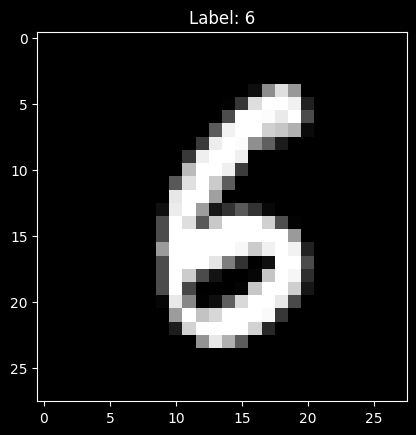

In [14]:
a_data, a_label = train_subset[100]

plt.imshow(a_data.squeeze(), cmap="gray")
plt.title(f"Label: {a_label}")
plt.show()

In [15]:
a_data.shape

torch.Size([1, 28, 28])

# Architecture

In [16]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

- `__init__` : 모델의 뼈대 만들기 
    - `conv1` : 입력 채널수 1, 출력 채널수 32 => 입력(28 * 28) -> 출력(28 * 28, 채널 32개)
    - `pool` : 2 * 2 크기로 가장 큰 값만 남김 => 입력(28 * 28) -> 출력(14 * 14)
    - `conv2` : 입력 채널 32, 출력 채널수 64 ==> 입력(14 * 14, 채널 32개) -> 출력(14 * 14, 채널 64개)
    - `fc1` : 7 * 7 사이즈로 줄어든 특징맵 64개를 1차원으로 펼침 ==> 64 * 7 * 7=3136개를 128개 뉴런으로 변환 
    - `fc2` : 128개 뉴런을 10개로 줄임 (10개 = 최종 라벨 개수)

- `forward` : 실제 데이터가 지나가는 길 
    - 입력 이미지 x (28 * 28) 들어오면...
    - conv1(x) : 32채널 28 * 28 출력 
    - pool : 32채널 14 * 14 출력 
    - conv2(x) : 64채널 14 * 14 출력 
    - pool : 64채널 7 * 7 출력 
    - x.view() : Flatten 처리 -> (batch_size, 64 * 7 * 7)
    - fc1(x) : 128개 뉴런 출력 
    - fc2(x) : 10개 뉴런 출력 

- 모델 흐름 

| Layer | Input size | Output size | Desc | 
|-------|------------|-------------|------|
| Conv1 + ReLU | (28, 28, 1) | (28, 28, 32) | 특징 추출 |
| MaxPool | (28, 28, 32) | (14, 14, 32) | 차원 축소 |
| Conv2 + ReLU | (14, 14, 32) | (14, 14, 64) | 더 깊은 특징 추출 |
| Maxpool | (14, 14, 64) | (7, 7, 64) | 차원 축소 |
| Flatten | (7, 7, 64) | (3136, ) | 펼치기 (2D->1D 변환) |
| fc1 + ReLU | (3136, ) | (128,) | 특징 결합 |
| fc2  | (128, ) | (10,) | 라벨 분류 (0~9 라벨) |

(참고)
- `super(CNN, self).__init__()`
    - `class CNN(nn.Module):`은 CNN이라는 새로운 구조를 만들되, 완전히 처음부터 만드는 것이 아니라 PyTorch가 이미 만들어놓은 `nn.Module`이라는 기본 설계도를 상속받아 만드는 것 
        - `nn.Module` : 겉으로는 안보이지만 파라미터 추적, `.to(device)`, `.train()`/`.eval()` 모드 전환, 가중치 저장/불러오기 등 필수 기능을 내부적으로 가지고 있는 부모 클래스 
    - 문제는 자식 클래스(CNN)가 `__init__`을 새로 선언하면 
        - 부모의 `__init__`은 자동으로 실행되지 않고 완전히 엎어써진다는 것 
        - 아무것도 안하면 부모가 준비한 필수 기능들이 세팅되지 않은 채로 실행 
        - 그래서 `super()__init__()`을 가장 먼저 호출하여 부모의 기본 셋팅을 먼저 그대로 실행하라고 선언하는 것이 필요 
        - 이후 그 다음줄 부터 CNN만의 기본 설계 내용을 추가 정의 

# Training

#### Setting

In [17]:
lr = 0.001

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

### Training

In [20]:
num_epochs = 10
train_losses = []
valid_losses = []
valid_accuracies = []

**Training 단계**

- `optimizer.zero_grad()` : 기울기 초기화 (이전 스텝 영향 제거) 
- `loss.backward()` : 오차(손실)에 대한 기울기 계산 
- `optimizer.step()` : 계산 기울기 기반으로 가중치 업데이트 
- loss 처리 
    - running_loss : 단계별 loss 누적 합 
    - len(train_loader) = batch 개수 
    - 나눠서 얻는 값 : epoch loss average 

In [21]:
for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # ---- Validation ----
    model.eval()
    valid_running_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            valid_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            valid_total += labels.size(0)
            valid_correct += (predicted == labels).sum().item()

    valid_losses.append(valid_running_loss / len(valid_loader))
    valid_accuracies.append(valid_correct / valid_total)

    print(
        f"Epoch {epoch + 1}, "
        f"Train Loss: {train_losses[-1]:.4f}, "
        f"Valid Loss: {valid_losses[-1]:.4f}, "
        f"Valid Accuracy: {valid_accuracies[-1]:.4f}"
    )


Epoch 1, Train Loss: 0.1384, Valid Loss: 0.0604, Valid Accuracy: 0.9830
Epoch 2, Train Loss: 0.0437, Valid Loss: 0.0557, Valid Accuracy: 0.9820
Epoch 3, Train Loss: 0.0298, Valid Loss: 0.0428, Valid Accuracy: 0.9877
Epoch 4, Train Loss: 0.0216, Valid Loss: 0.0487, Valid Accuracy: 0.9863
Epoch 5, Train Loss: 0.0174, Valid Loss: 0.0376, Valid Accuracy: 0.9903
Epoch 6, Train Loss: 0.0132, Valid Loss: 0.0476, Valid Accuracy: 0.9878
Epoch 7, Train Loss: 0.0113, Valid Loss: 0.0398, Valid Accuracy: 0.9898
Epoch 8, Train Loss: 0.0085, Valid Loss: 0.0485, Valid Accuracy: 0.9900
Epoch 9, Train Loss: 0.0083, Valid Loss: 0.0580, Valid Accuracy: 0.9875
Epoch 10, Train Loss: 0.0073, Valid Loss: 0.0503, Valid Accuracy: 0.9900


# Evaluation

In [22]:
def evaluate(model, loader, collect_misclassified=False):
    """loader에 대한 accuracy를 계산. collect_misclassified=True면 오분류 샘플도 함께 수집"""
    model.eval()
    correct = 0
    total = 0
    misclassified = []

    # eval 단계에서는 gradient 계산 불필요
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            # 가장 높은 확률을 가진 클래스 선택
            _, predicted = torch.max(outputs, 1)

            # 전체 샘플수 누적
            total += labels.size(0)

            # 정답과 예측이 일치하는 샘플수 누적
            correct += (predicted == labels).sum().item()

            if collect_misclassified:
                # 오분류 샘플의 인덱스 추출
                wrong_idx = (predicted != labels).nonzero(as_tuple=True)[0]

                # 오분류 샘플 취합 (입력데이터, 예측값, 실제값)
                for idx in wrong_idx:
                    misclassified.append(
                        (inputs[idx].cpu(), predicted[idx].cpu(), labels[idx].cpu())
                    )

    accuracy = correct / total
    return accuracy, misclassified


In [23]:
train_accuracy, _ = evaluate(model, train_loader)
valid_accuracy, _ = evaluate(model, valid_loader)
test_accuracy, misclassified_samples = evaluate(model, test_loader, collect_misclassified=True)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Valid Accuracy: {valid_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Train Accuracy: 0.9986
Valid Accuracy: 0.9900
Test Accuracy: 0.9904


## Training Loss

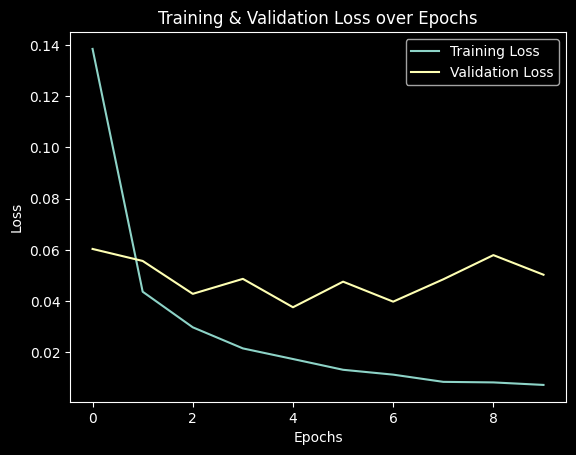

In [25]:
plt.plot(train_losses, label="Training Loss")
plt.plot(valid_losses, label="Validation Loss")

plt.title("Training & Validation Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

그래프 해석
- Training Loss 
    - 0.14로 시작해 이후 지속적으로 감소 
    - epoch 10에서는 약 0.007까지 떨어짐 
    - 감소 폭이 크고 단조롭게 줄어드는 형태 
- Validation Loss
    - epoch 0에서 약 0.06으로 시작해 epoch 2까지는 함께 감소
    - 이후 뚜렷한 하락 없이 0.04~0.06 구간에서 등락 반복 
- 종합
    - training loss는 계속 낮아지는 반면, validation loss는 epoch 2~3 이후 정체 및 등락 -> 두 곡선 간 격차가 벌어지는 양상 
    - 모델이 학습 데이터에는 점점 더 잘 맞춰지지만, epoch 진행될수록 성능이 개선되지 않음 -> overfitting 초기 신호로 해석 가능 

## Results

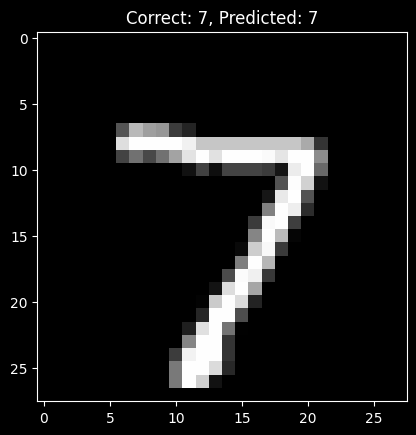

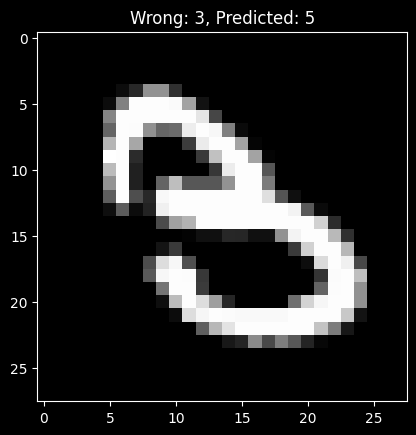

In [26]:
correct_sample = None
for i in range(len(test_set)):
    img, label = test_set[i]
    img_tensor = img.unsqueeze(0).to(device)
    output = model(img_tensor)
    _, pred = torch.max(output, 1)
    if pred.item() == label:
        correct_sample = (img, label, pred.item())
        break

if correct_sample:
    plt.imshow(correct_sample[0].squeeze(), cmap="gray")
    plt.title(f"Correct: {correct_sample[1]}, Predicted: {correct_sample[2]}")
    plt.show()

# 틀린 것
if misclassified_samples:
    img, pred, label = misclassified_samples[0]
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"Wrong: {label}, Predicted: {pred}")
    plt.show()

---
End of Documents